# Case Study
- **Goal**: A farmer seeks a predictive model to determine whether the paddy yield per hectare for a given agriblock (a defined unit of agricultural land) exceeds the mean paddy yield per hectare

In [40]:
# Essential packages
import pandas as pd
import numpy as np
import seaborn as sns
import pickle
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, auc, classification_report

In [41]:
file_name = 'Asm1_dataset26.csv'
df = pd.read_csv(file_name)
df.head(5)

,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,...,--,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,SSE,W,SW,NW,72.7,91,83,81,600,34044


In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2789 entries, 0 to 2788
Data columns (total 45 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Hectares                            2789 non-null   int64  
 1   Agriblock                           2789 non-null   str    
 2   Variety                             2789 non-null   str    
 3   Soil Types                          2789 non-null   str    
 4   Seedrate(in Kg)                     2789 non-null   int64  
 5   LP_Mainfield(in Tonnes)             2789 non-null   float64
 6   Nursery                             2789 non-null   str    
 7   Nursery area (Cents)                2789 non-null   int64  
 8   LP_nurseryarea(in Tonnes)           2789 non-null   int64  
 9   DAP_20days                          2789 non-null   int64  
 10  Weed28D_thiobencarb                 2789 non-null   int64  
 11  Urea_40Days                         2789 non-null   fl

## Task 1. Data Preparation
* What variables are included in the modelling, their roles and measurement level set and why?
* Any data issues addressed? Describe the step to transform/clean the data
* Create a new binary column named 'isAboveAvg' as the target variable, where the value is set to 1 if the paddy field per hectare exceeds the mean paddy yield per hectare, and 0 otherwise. Reorganize the dataset by removing potentially noisy or non-informative columns, such as Hectares, Paddy Yield, etc.
* Identify and remove highly correlated columns with a pairwise correlation coefficient greater than 0.98

In [43]:
# Cleaning the data
df.columns = df.columns.str.strip() # Column Hectares has a redundant space
print(f'Original dataset: {df.shape}')

# Identify duplicated rows
print(f'Number of duplicated rows: {df.duplicated().sum()}')

# Remove duplicated rows
df = df.drop_duplicates(keep='first')
print(f'Cleaned dataset: {df.shape}')

Original dataset: (2789, 45)
Number of duplicated rows: 161
Cleaned dataset: (2628, 45)


In [44]:
# Identify missing values
missing_value = df.isnull().sum()
print(f'Missing values per columns:\n{missing_value[missing_value > 0]}')

Missing values per columns:
Min temp_D1_D30      107
Min temp_D31_D60     107
Min temp_D61_D90     107
Min temp_D91_D120    107
dtype: int64


In [45]:
# Impute missing values with its median
cols = ['Min temp_D1_D30', 'Min temp_D31_D60', 'Min temp_D61_D90', 'Min temp_D91_D120']
for col in cols:
    df[col] = df[col].fillna(df[col].median())
    print(col, df[col].unique().tolist())

# Replace '--' with NA in categorical variables
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].replace('--', 'NA')
    print(col, df[col].unique().tolist())

Min temp_D1_D30 [18.5, 19.5, 20.0, 19.0, 20.5, 18.0]
Min temp_D31_D60 [16.0, 18.5, 18.0, 17.0, 17.5, 15.5]
Min temp_D61_D90 [15.5, 17.0, 17.5, 16.5, 18.0, 15.0]
Min temp_D91_D120 [16.0, 18.0, 15.5, 16.5, 15.0]
Agriblock ['Cuddalore', 'Kurinjipadi', 'Panruti', 'Kallakurichi', 'Sankarapuram', 'Chinnasalem']
Variety ['CO_43', 'ponmani', 'delux ponni']
Soil Types ['alluvial', 'clay']
Nursery ['dry', 'wet']
Wind Direction_D1_D30 ['SW', 'NW', 'ENE', 'NA', 'SSE', 'E', 'W']
Wind Direction_D31_D60 ['W', 'S', 'NE', 'WNW', 'ENE', 'NA']
Wind Direction_D61_D90 ['NNW', 'SE', 'NNE', 'SW', 'NE', 'NA']
Wind Direction_D91_D120 ['WSW', 'SSE', 'W', 'S', 'NW', 'NNW', 'NA']


/var/folders/p7/wgz8z2r94nqgs81btq4zyn_80000gn/T/ipykernel_95864/3533552040.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [46]:
# Calculate the mean of the paddy yield per hectares
df['yield_per_hec'] = df['Paddy yield(in Kg)']/df['Hectares'] 
mean_yield = df['yield_per_hec'].mean()
print(f'Mean yield per hec: {mean_yield:.2f}')

# Create a column name 'isAboveAvg'
df['isAboveAvg'] = np.where(df['yield_per_hec'] > mean_yield, 1, 0)
df['isAboveAvg'].value_counts()

Mean yield per hec: 5990.15


isAboveAvg
0    1327
1    1301
Name: count, dtype: int64

In [47]:
# Check which columns are exactly proportional to Hectares
constant_ratio_cols = []
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    # Exclude variables dropped for another reason
    if col not in ['Hectares', 'Paddy yield(in Kg)', 'yield_per_hec', 'Trash(in bundles)']:
        ratio = df[col] / df['Hectares']
        if ratio.nunique() == 1:
            constant_ratio_cols.append(col)
            unique_count = ratio.nunique()
            constant_val = ratio.iloc[0]
            print(f"{col:<35s} unique_count={unique_count:<13} constant_ratio={constant_val:.2f} <- redundant")

Seedrate(in Kg)                     unique_count=1             constant_ratio=25.00 <- redundant
LP_Mainfield(in Tonnes)             unique_count=1             constant_ratio=12.50 <- redundant
Nursery area (Cents)                unique_count=1             constant_ratio=20.00 <- redundant
LP_nurseryarea(in Tonnes)           unique_count=1             constant_ratio=1.00 <- redundant
DAP_20days                          unique_count=1             constant_ratio=40.00 <- redundant
Weed28D_thiobencarb                 unique_count=1             constant_ratio=2.00 <- redundant
Micronutrients_70Days               unique_count=1             constant_ratio=15.00 <- redundant
Pest_60Day(in ml)                   unique_count=1             constant_ratio=600.00 <- redundant


In [48]:
# Drop noisy columns
drop_cols = ['Hectares', 'Paddy yield(in Kg)', 'yield_per_hec', 'Trash(in bundles)'] + constant_ratio_cols
df_clean = df.drop(columns = drop_cols)
df_clean.info()

<class 'pandas.DataFrame'>
Index: 2628 entries, 0 to 2788
Data columns (total 35 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Agriblock                           2628 non-null   str    
 1   Variety                             2628 non-null   str    
 2   Soil Types                          2628 non-null   str    
 3   Nursery                             2628 non-null   str    
 4   Urea_40Days                         2628 non-null   float64
 5   Potassh_50Days                      2628 non-null   float64
 6   30DRain( in mm)                     2628 non-null   float64
 7   30DAI(in mm)                        2628 non-null   float64
 8   30_50DRain( in mm)                  2628 non-null   float64
 9   30_50DAI(in mm)                     2628 non-null   float64
 10  51_70DRain(in mm)                   2628 non-null   float64
 11  51_70AI(in mm)                      2628 non-null   float64

In [49]:
# Correlation Analysis
## Encode categorical columns with One-hot encoding
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

# Separate input and target variables
X = df_encoded.drop(columns=['isAboveAvg'])
y = df_encoded['isAboveAvg']

corr_matrix = X.corr().abs()

# Find highly correlated pair-wise columns
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.98)]

print(f"Highly correlated columns to drop {len(high_corr_cols)}:")
for col in high_corr_cols:
    pairs = upper_triangle.index[upper_triangle[col] > 0.98].tolist()
    for pair in pairs:
        print(f" {pair} <-> {col}: r = {upper_triangle.loc[pair, col]:.4f}")

# Drop highly correlated columns
df_final = X.drop(columns=high_corr_cols)
print(f"Final feature set: {df_final.shape}")

Highly correlated columns to drop 7:
 Urea_40Days <-> Potassh_50Days: r = 1.0000
 30DRain( in mm) <-> 30DAI(in mm): r = 1.0000
 30_50DRain( in mm) <-> 30_50DAI(in mm): r = 1.0000
 51_70DRain(in mm) <-> 51_70AI(in mm): r = 1.0000
 30_50DRain( in mm) <-> 71_105DRain(in mm): r = 1.0000
 30_50DAI(in mm) <-> 71_105DRain(in mm): r = 1.0000
 30_50DRain( in mm) <-> 71_105DAI(in mm): r = 1.0000
 30_50DAI(in mm) <-> 71_105DAI(in mm): r = 1.0000
 71_105DRain(in mm) <-> 71_105DAI(in mm): r = 1.0000
 Min temp_D1_D30 <-> Min temp_D61_D90: r = 0.9923
Final feature set: (2628, 50)


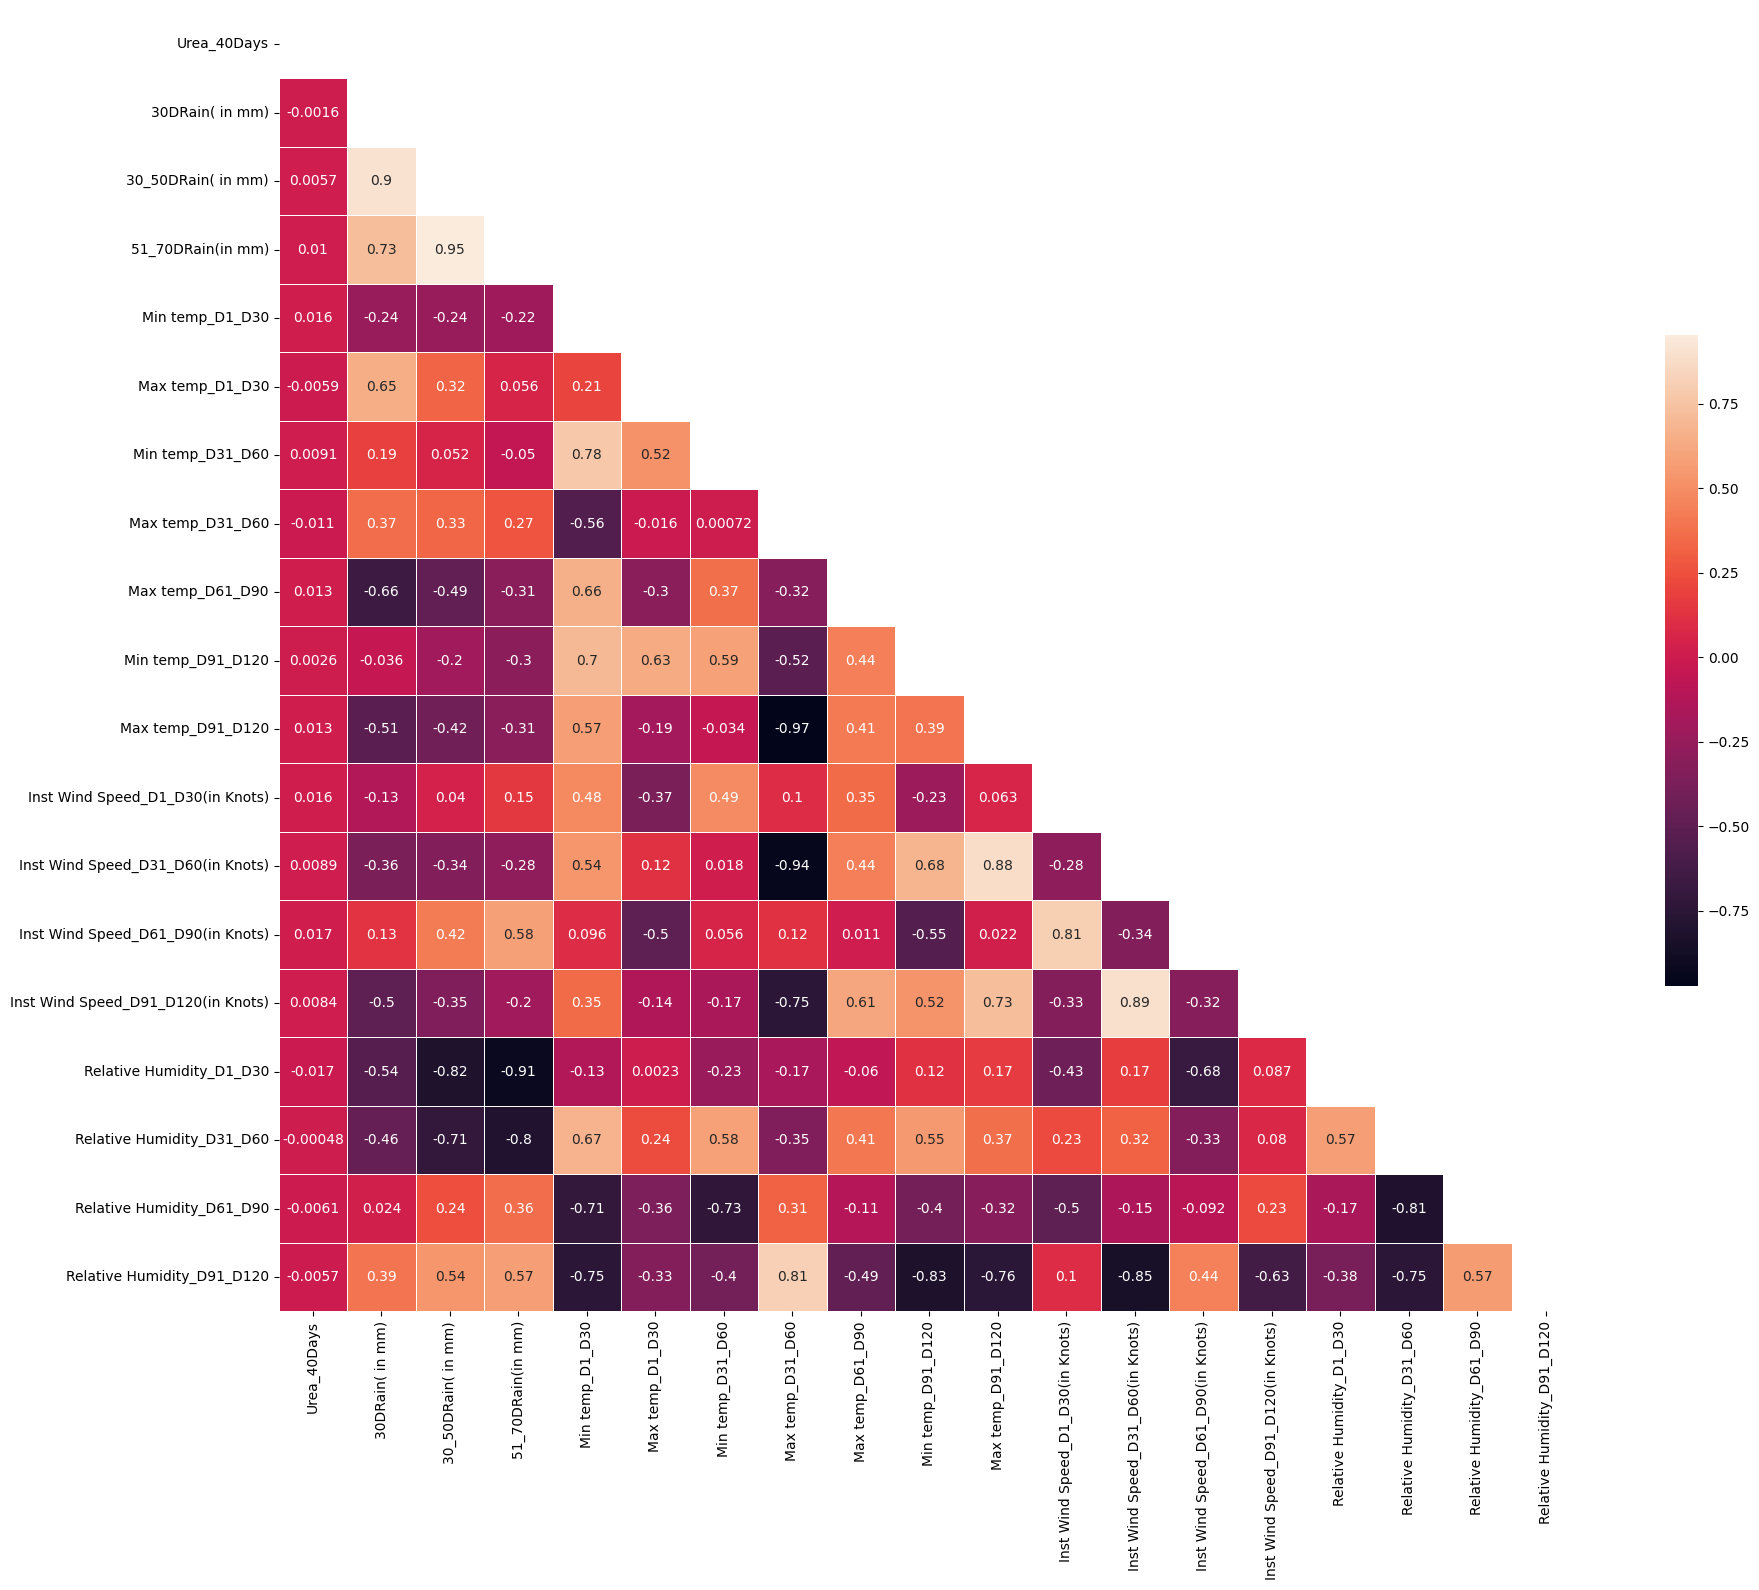

In [50]:
# Correlation Heatmap (After Cleaning)
numeric_df = df_final.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, mask=mask, square=True, linewidths=0.5, cbar_kws={"shrink": 0.5}, annot=True)
plt.tight_layout()
plt.show()

## Task 2. Decision Tree modelling (4 marks)
* Build a decision tree using the default setting, examine the tree results and answer the questions:
    * What parameters have been used to build the tree? Detail them
    * What data split was used to create training and test datasets?
    * What is the classification accuracy on the training and test datasets?
    * What is the size of the tree (number of nodes and rules)?
    * Which variables is used for the first split? What are the variables that are used for the second split?
    * What are the 10 important variables in build the tree?
* Build another decision tree tuned with GridSearchCV. Examine the result:
    * What are the optimal parameters for this decision tree? Explain your choice of hyperparameters to search, and the chosen search range(s)?
    * What is the classification accuracy on the training the test datasets?
    * What is the size of the chosen tree (number of nodes and rules)?
    * Which variable is used for the first split? What are the variables that are used for the 2nd split?
    * What are the 10 important variables in building the tree?
    * Report which decision tree model exhibits significant evidence of overfitting 
* What is the significant difference between these 2 decision tree models? Visualize the trees and list some of the rules where the class is positive (target variable = 1)
* Produce the ROC curve for both decision tree models. Compare the performance of the 2 models and analyze the key variables (features) they utilize

### 2.1. Decision Tree with default setting

In [51]:
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(df_final, y, test_size=0.3, 
                                                    random_state=RANDOM_STATE, stratify=y)

print("Size of training set:", len(X_train))
print("Size of testing set:", len(X_test))

Size of training set: 1839
Size of testing set: 789


In [52]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

Q1. What parameters have been used to build the tree?

In [53]:
for p, v in dt.get_params().items():
    print(f'{p}: {v}')

ccp_alpha: 0.0
class_weight: None
criterion: gini
max_depth: None
max_features: None
max_leaf_nodes: None
min_impurity_decrease: 0.0
min_samples_leaf: 1
min_samples_split: 2
min_weight_fraction_leaf: 0.0
monotonic_cst: None
random_state: 42
splitter: best


Q2. What data split was used to create training and test datasets?

In [54]:
train_size = (len(X_train) / len(df_final)) * 100
test_size = 100 - train_size
print(f'Train size: {train_size:.2f}%')
print(f'Test size: {test_size:.2f}%')

Train size: 69.98%
Test size: 30.02%


Q3. What is the classification accuracy on the training and test datatset?

In [55]:
train_acc = accuracy_score(y_train, dt.predict(X_train)) * 100
test_acc = accuracy_score(y_test, dt.predict(X_test)) * 100
print(f'Training accuracy: {train_acc:.2f}%\nTest accuracy: {test_acc:.2f}%')

Training accuracy: 93.69%
Test accuracy: 82.89%


Q4. What is the size of the tree (number of nodes and rules)?

In [56]:
print(f'Total nodes: {dt.tree_.node_count} nodes')
print(f'Rules: {dt.tree_.n_leaves} leaves')

Total nodes: 511 nodes
Rules: 256 leaves


Q5. Which variable is used for the first split? What are the variables that are used for the second split?

In [57]:
tree = dt.tree_
feature_names = X_train.columns
first_feature = feature_names[tree.feature[0]]
left_child = tree.children_left[0]
right_child = tree.children_right[0]
print(f'First split: {first_feature}')
print(f'Second split:')
print(f'Left: {feature_names[tree.feature[left_child]]}')
print(f'Right: {feature_names[tree.feature[right_child]]}')

First split: Urea_40Days
Second split:
Left: Wind Direction_D31_D60_W
Right: Urea_40Days


Q6. What are the 10 important features in building the tree?

In [58]:
important_features = pd.DataFrame({'Feature': feature_names, 'Importance': dt.feature_importances_})
important_features.sort_values(by='Importance', ascending=False).head(10)

,Feature,Importance
0,Urea_40Days,0.815453
24,Variety_delux ponni,0.031702
25,Variety_ponmani,0.025839
27,Nursery_wet,0.024829
26,Soil Types_clay,0.023505
6,Min temp_D31_D60,0.008142
29,Wind Direction_D1_D30_NA,0.006941
16,Relative Humidity_D31_D60,0.004965
8,Max temp_D61_D90,0.004698
45,Wind Direction_D91_D120_NW,0.004116


### 2.2. Decision tree tuned with GridSearchCV

2.2.a. What are the optimal parameters for this decision tree? Explain your choice of hyperparameters to search, and the chosen search range(s)?

In [59]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_dt = grid_search.best_estimator_
print(f'Optimal Parameters:\n{grid_search.best_params_}')

Optimal Parameters:
{'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


Reasoning:
- 'gini' and 'entropy' are the 2 standard impurity metrics and there are no other metrics
- 'max_depth':
    + 'None' to see if the other constrains (e.g. min_samples_*) could fix the tree on their own
    + [3, 5, 7, 10, 15] are the standard and small range to immediately avoid overfit
- 'min_samples_split' & 'min_samples_leaf': we use the recommend default range searched on the internet

2.2.b. What is the classification accuracy on the training and test datasets?

In [60]:
train_acc = accuracy_score(y_train, best_dt.predict(X_train)) * 100
test_acc = accuracy_score(y_test, best_dt.predict(X_test)) * 100
print(f'Training accuracy: {train_acc:.2f}%')
print(f'Test accuracy: {test_acc:.2f}%')

Training accuracy: 90.32%
Test accuracy: 90.24%


2.2.b. What is the size of the chosen tree (number of nodes and rules)?

In [61]:
print(f'Number of nodes: {best_dt.tree_.node_count} nodes')
print(f'Number of rules: {best_dt.tree_.n_leaves} leaves')

Number of nodes: 13 nodes
Number of rules: 7 leaves


2.2.c. What variable is used for the first split? What are the variables that are used for the second split?

In [62]:
tree = best_dt.tree_
feature_names = X_train.columns
first_feature = feature_names[tree.feature[0]]
left_child = tree.children_left[0]
right_child = tree.children_right[0]
print(f'First split: {first_feature}')
print(f'Second split:')
print(f'Left: {feature_names[tree.feature[left_child]]}')
print(f'Right: {feature_names[tree.feature[right_child]]}')

First split: Urea_40Days
Second split:
Left: Wind Direction_D31_D60_W
Right: Urea_40Days


2.2.d. What are the 10 important variables in building a tree?

In [63]:
important_features = pd.DataFrame({'Feature': feature_names, 'Importance': best_dt.feature_importances_})
important_features.sort_values(by='Importance', ascending=False).head(10)

,Feature,Importance
0,Urea_40Days,0.968638
24,Variety_delux ponni,0.030974
25,Variety_ponmani,0.000266
37,Wind Direction_D31_D60_W,0.000123
3,51_70DRain(in mm),0.000000
38,Wind Direction_D31_D60_WNW,0.000000
29,Wind Direction_D1_D30_NA,0.000000
30,Wind Direction_D1_D30_NW,0.000000
31,Wind Direction_D1_D30_SSE,0.000000
32,Wind Direction_D1_D30_SW,0.000000


2.2.e. Report which decision tree model exhibits significant evidence of overfitting

* The Default Tree exhibits significant overfitting as the accuracy gap between the training (93.69%) and test (83.02%) is high (~10.67%). Whereas, in the second tuned tree using GridSearchCV, the gap is smaller
(~0.08%) with training accuracy and test accuracy are 90.32% and 90.24% respectively

* Furthermore, the first tree created 255 hyper-specific rules (leaves) to perfectly categorize the training data. The second tree achieved a better accuracy using only 7 rules (~only 2% of the default tree).

### 3. What is the significant difference between these two decision tree models – default (Task 2.1) and using GridSearchCV (Task 2.2)? Visualize the trees and list some of the rules where the class is positive (the target variable = 1).

The fundamental difference between the Default Decision Tree and the GridSearchCV Tuned Decision Tree comes down to Overfitting versus Generalization:

* The Default Tree (Unconstrained): It was allowed to grow to an infinite depth until every single leaf node was perfectly pure. This resulted in a massive, overly complex tree (255 rules). It simply memorized the training data (capturing noise and outliers), which caused its accuracy to drop significantly when tested on unseen data.

* The Tuned Tree (Constrained): By enforcing hyperparameters like max_depth=3 and min_samples_split=2, we forced the tree to stop growing early. This pruned away the hyper-specific, noisy rules and left only the broadest, most reliable patterns. It is mathematically simpler (only 7 rules) but performs much better on new data.

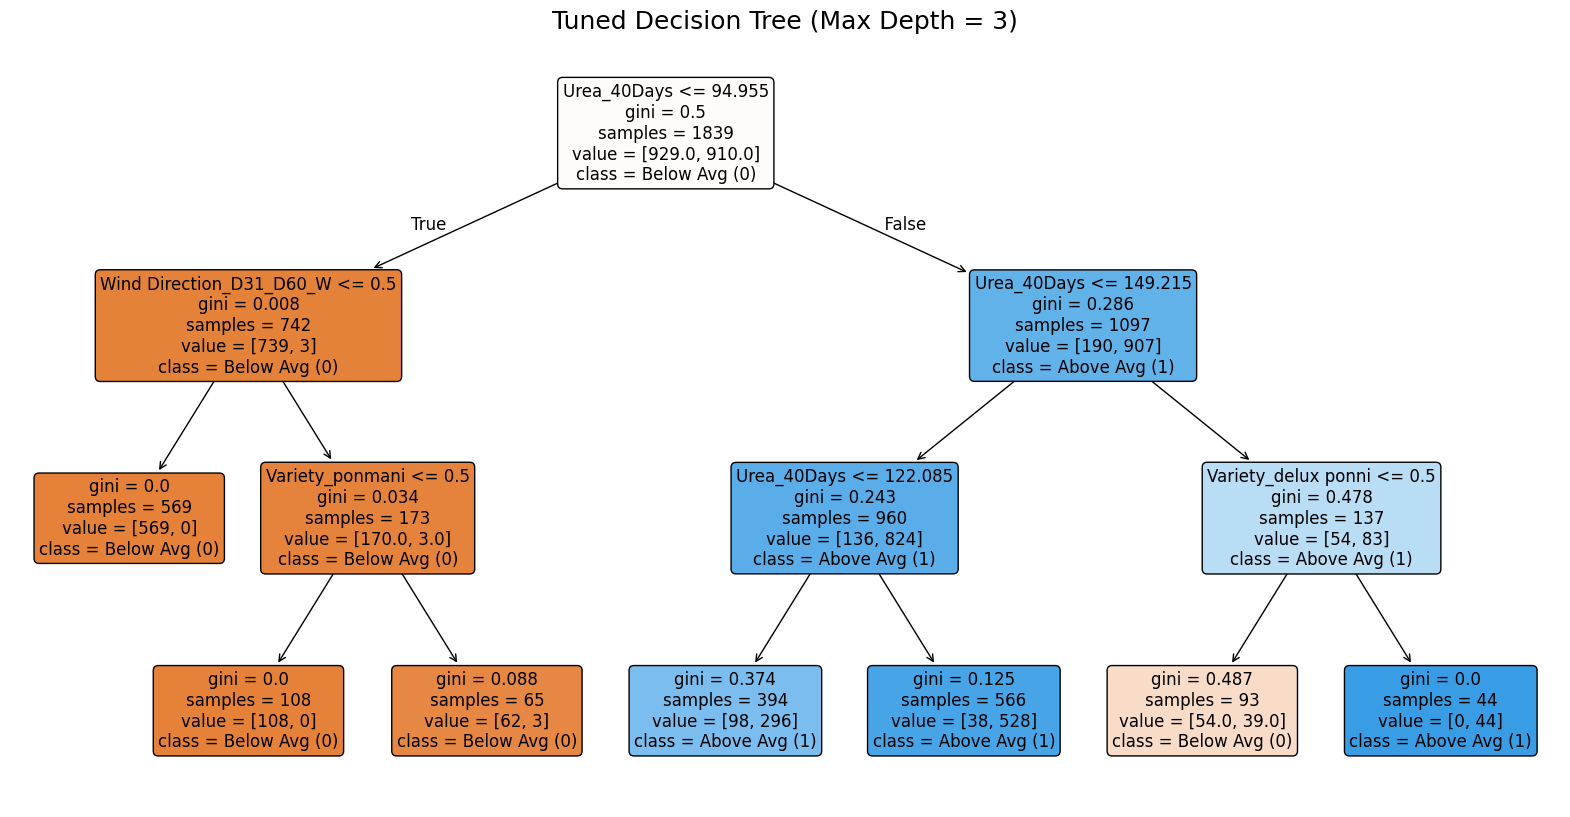

In [64]:
# Set up a figure
plt.figure(figsize=(20, 10))

# Plot the tuned tree
plot_tree(best_dt, 
          feature_names=X_train.columns, 
          class_names=['Below Avg (0)', 'Above Avg (1)'], 
          filled=True, 
          rounded=True, 
          fontsize=12)

plt.title("Tuned Decision Tree (Max Depth = 3)", fontsize=18)
plt.show()

### 4. Produce the ROC curve for both decision tree models. Compare the performance of the two models and analyze the key variables (features) they utilize.

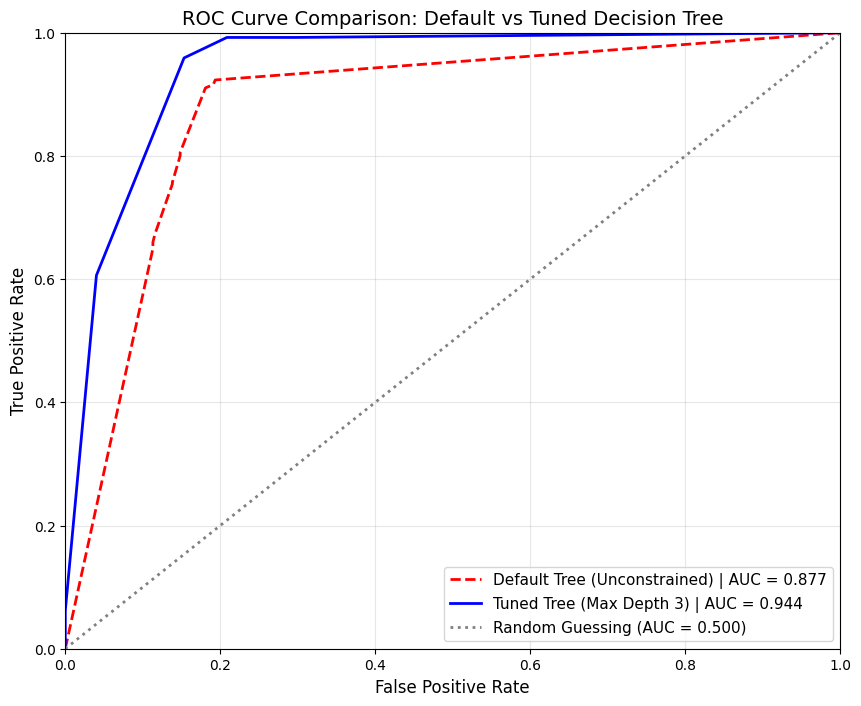

In [65]:
y_prob_dt = dt.predict_proba(X_test)[:, 1]
y_prob_best_dt = best_dt.predict_proba(X_test)[:, 1]

# Calculate FPR, TPR, AUC for default tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = auc(fpr_dt, tpr_dt)

# Calculate FPR, TPR, AUC for tuned tree
fpr_best_dt, tpr_best_dt, _ = roc_curve(y_test, y_prob_best_dt)
auc_best_dt = auc(fpr_best_dt, tpr_best_dt)

# ROC plotting
plt.figure(figsize=(10, 8))

# Default Tree
plt.plot(fpr_dt, tpr_dt, color='red', lw=2, linestyle='--',
         label=f'Default Tree (Unconstrained) | AUC = {auc_dt:.3f}')

# Tuned Tree
plt.plot(fpr_best_dt, tpr_best_dt, color='blue', lw=2, 
         label=f'Tuned Tree (Max Depth 3) | AUC = {auc_best_dt:.3f}')

# Baseline
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle=':', label='Random Guessing (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison: Default vs Tuned Decision Tree', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

plt.show()

In [66]:
# Save final_df and best params for later tasks
df_final.to_csv('df_final_features.csv', index=False)

with open('best_dt_params.json', 'w') as f:
    json.dump(grid_search.best_params_, f, indent=2, default=str)

# Save both decision tree models
with open('decision_tree_default.pickle', 'wb') as f:
    pickle.dump([dt, auc_dt, fpr_dt, tpr_dt], f)

with open('decision_tree_tuned.pickle', 'wb') as f:
    pickle.dump([best_dt, auc_dt, fpr_dt, tpr_dt], f)

## Task 3. Logistics Regression

### 1. Describe which regression model was selected for the classification problem and what additional processing was required on this dataset to be used in regression modelling. List the variables that need further processing and provide detail of the processing

* As the output of the classification is binary ('isAboveAvg' as 0 and 1), the model should be used is Logistic Regression. As the previous method, Decision Tree, does not care about the scale of the data, we need additional processing. Logistic Regression, on the other hand, is sensitive to the data scale. For example, if 1 variable is measure in thousands, and another in decimals, the model will struggle to find the right weights. That's why feature scaling is needed for this step.
* Variables that need further processing including all continuous or numeric variables, which are:

In [67]:
# Continuous or numeric columns that need further processing
numeric_cols = df_final.select_dtypes(include=['int64', 'float64']).columns.tolist()
# print(numeric_cols)

print(df_final.info())

<class 'pandas.DataFrame'>
Index: 2628 entries, 0 to 2788
Data columns (total 50 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Urea_40Days                         2628 non-null   float64
 1   30DRain( in mm)                     2628 non-null   float64
 2   30_50DRain( in mm)                  2628 non-null   float64
 3   51_70DRain(in mm)                   2628 non-null   float64
 4   Min temp_D1_D30                     2628 non-null   float64
 5   Max temp_D1_D30                     2628 non-null   int64  
 6   Min temp_D31_D60                    2628 non-null   float64
 7   Max temp_D31_D60                    2628 non-null   int64  
 8   Max temp_D61_D90                    2628 non-null   float64
 9   Min temp_D91_D120                   2628 non-null   float64
 10  Max temp_D91_D120                   2628 non-null   float64
 11  Inst Wind Speed_D1_D30(in Knots)    2628 non-null   int64  

### 2. Build regression model tuned with GridSearchCV

In [68]:
numeric_col_names = df_final.select_dtypes(include=['int64', 'float64']).columns.tolist()

scaler = StandardScaler()

print("*************************")
print("Before scaling")
print("*************************")
for col_name in numeric_col_names[:5]:
    col = X_train[col_name]
    print(f"{col_name:<20s} | min: {col.min():6.2f}, max: {col.max():6.2f}, mean: {col.mean():6.2f}, std: {col.std():6.2f}")

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_col_names] = scaler.fit_transform(X_train[numeric_col_names])
X_test_scaled[numeric_col_names] = scaler.transform(X_test[numeric_col_names])

print("\n*************************")
print("After scaling")
print("*************************")
for col_name in numeric_col_names[:5]:
    col = X_train_scaled[col_name]
    print(f"{col_name:<20s} | min: {col.min():6.2f}, max: {col.max():6.2f}, mean: {col.mean():6.2f}, std: {col.std():6.2f}")

*************************
Before scaling
*************************
Urea_40Days          | min:  27.13, max: 162.78, mean: 101.20, std:  39.18
30DRain( in mm)      | min:  18.10, max:  19.60, mean:  18.70, std:   0.64
30_50DRain( in mm)   | min: 185.20, max: 187.20, mean: 185.99, std:   0.84
51_70DRain(in mm)    | min: 165.30, max: 167.00, mean: 166.15, std:   0.67
Min temp_D1_D30      | min:  18.00, max:  20.50, mean:  19.36, std:   0.86

*************************
After scaling
*************************
Urea_40Days          | min:  -1.89, max:   1.57, mean:  -0.00, std:   1.00
30DRain( in mm)      | min:  -0.94, max:   1.41, mean:  -0.00, std:   1.00
30_50DRain( in mm)   | min:  -0.94, max:   1.43, mean:  -0.00, std:   1.00
51_70DRain(in mm)    | min:  -1.26, max:   1.28, mean:   0.00, std:   1.00
Min temp_D1_D30      | min:  -1.58, max:   1.33, mean:  -0.00, std:   1.00


In [69]:
params = {
    # 'C': [pow(10, x) for x in range(-6, 4)],
    "C": [pow(10, x) for x in range(-4, 4)],  # Reduce the range
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"],
}

lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=5000)
cv = GridSearchCV(
    param_grid=params,
    estimator=lr,
    cv=10,
    n_jobs=-1,
)

cv.fit(X_train_scaled, y_train)

print(f"Train accuracy: {cv.score(X_train_scaled, y_train)*100:.2f}%")
print(f"Test accuracy: {cv.score(X_test_scaled, y_test)*100:.2f}%")

y_pred = cv.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

best_lr_model = cv.best_estimator_
print(f"The optimal parameter is: {cv.best_params_}")

/Users/harrychow/Documents/IFN580-ML-assignment1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/harrychow/Documents/IFN580-ML-assignment1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/harrychow/Documents/IFN580-ML-assignment1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. U

Train accuracy: 89.51%
Test accuracy: 89.10%
              precision    recall  f1-score   support

           0       0.99      0.79      0.88       398
           1       0.82      0.99      0.90       391

    accuracy                           0.89       789
   macro avg       0.91      0.89      0.89       789
weighted avg       0.91      0.89      0.89       789

The optimal parameter is: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}


/Users/harrychow/Documents/IFN580-ML-assignment1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/harrychow/Documents/IFN580-ML-assignment1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [70]:
coef = best_lr_model.coef_[0]
feature_names = df_final.columns[:X_train_scaled.shape[1]]

indices = np.argsort(np.absolute(coef))
indices = np.flip(indices, axis=0)

indices = indices[:10] 

for i in indices:
    print(feature_names[i], ':', coef[i])

Urea_40Days : 1.6541765057144453
Inst Wind Speed_D31_D60(in Knots) : 0.0
Agriblock_Panruti : 0.0
Agriblock_Kurinjipadi : 0.0
Agriblock_Kallakurichi : 0.0
Agriblock_Cuddalore : 0.0
Relative Humidity_D91_D120 : 0.0
Relative Humidity_D61_D90 : 0.0
Relative Humidity_D31_D60 : 0.0
Relative Humidity_D1_D30 : 0.0


In [71]:
# Train and Test accuracy
print(f"Train accuracy: {cv.score(X_train_scaled, y_train)*100:.2f}%")
print(f"Test accuracy: {cv.score(X_test_scaled, y_test)*100:.2f}%")

Train accuracy: 89.51%
Test accuracy: 89.10%


### 3. Build regression model with reduced variables set

In [72]:
# Reuse the tuned decision tree model from Task 2
with open('decision_tree_tuned.pickle', 'rb') as f:
    best_clf = pickle.load(f)

selectmodel = SelectFromModel(best_clf[0], prefit=True)
X_train_sel_model = selectmodel.transform(X_train_scaled)
X_test_sel_model = selectmodel.transform(X_test_scaled)

selected_mask = selectmodel.get_support()
selected_features = feature_names[selected_mask]

print("The selected features by the decision tree are:")
for i, feature in enumerate(selected_features):
    print(f"{i+1}. {feature}")

The selected features by the decision tree are:
1. Urea_40Days
2. Variety_delux ponni


/Users/harrychow/Documents/IFN580-ML-assignment1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/Users/harrychow/Documents/IFN580-ML-assignment1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [73]:
params = {
    # 'C': [pow(10, x) for x in range(-6, 4)],
    "C": [pow(10, x) for x in range(-4, 4)],  # Reduce the range
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"],
}

reduced_lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=5000)
cv_sel_model = GridSearchCV(
    param_grid=params,
    estimator=reduced_lr,
    cv=10,
    n_jobs=-1,
)

cv_sel_model.fit(X_train_sel_model, y_train)

print(f"Train accuracy: {cv_sel_model.score(X_train_sel_model, y_train)*100:.2f}%")
print(f"Test accuracy: {cv_sel_model.score(X_test_sel_model, y_test)*100:.2f}%")

y_pred = cv_sel_model.predict(X_test_sel_model)
print(classification_report(y_test, y_pred))

best_cv_sel_model = cv_sel_model.best_estimator_
print(f"The optimal parameter is: {cv_sel_model.best_params_}")

/Users/harrychow/Documents/IFN580-ML-assignment1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/harrychow/Documents/IFN580-ML-assignment1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/harrychow/Documents/IFN580-ML-assignment1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. U

Train accuracy: 89.51%
Test accuracy: 89.10%
              precision    recall  f1-score   support

           0       0.99      0.79      0.88       398
           1       0.82      0.99      0.90       391

    accuracy                           0.89       789
   macro avg       0.91      0.89      0.89       789
weighted avg       0.91      0.89      0.89       789

The optimal parameter is: {'C': 0.0001, 'penalty': 'l2', 'solver': 'liblinear'}


/Users/harrychow/Documents/IFN580-ML-assignment1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/harrychow/Documents/IFN580-ML-assignment1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/harrychow/Documents/IFN580-ML-assignment1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: 

### 4. ROC curve and performance comparison

ROC index on test for `cv`: 0.8975536249020036
ROC index on test for `cv_sel_model`: 0.9052069811975478


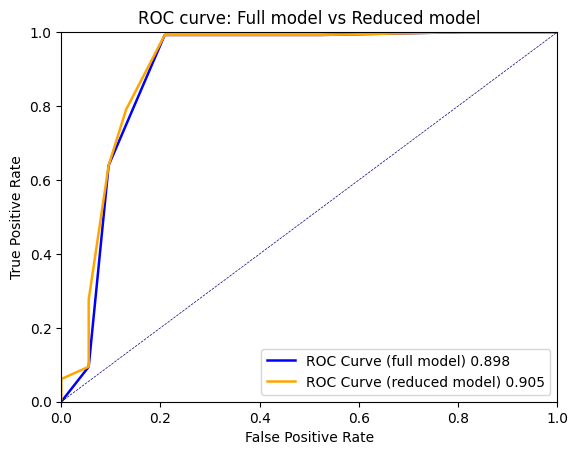

In [74]:
from sklearn.metrics import roc_auc_score, roc_curve
from matplotlib import pyplot as plt

y_pred_proba_lr_cv = cv.predict_proba(X_test_scaled)
y_pred_proba_cv_sel_model = cv_sel_model.predict_proba(X_test_sel_model)

roc_index_lr_cv = roc_auc_score(y_test, y_pred_proba_lr_cv[:, 1])
roc_index_cv_sel_model = roc_auc_score(y_test, y_pred_proba_cv_sel_model[:, 1])

print("ROC index on test for `cv`:", roc_index_lr_cv)
print("ROC index on test for `cv_sel_model`:", roc_index_cv_sel_model)

# ROC curve
fpr_lr_cv, tpr_lr_cv, thresholds_lr_cv = roc_curve(y_test, y_pred_proba_lr_cv[:, 1])
fpr_cv_sel_model, tpr_cv_sel_model, thresholds_cv_sel_model = roc_curve(
    y_test, y_pred_proba_cv_sel_model[:, 1]
)

plt.plot(
    fpr_lr_cv,
    tpr_lr_cv,
    label=f"ROC Curve (full model) {roc_index_lr_cv:.3f}",
    color="blue",
    lw=1.8,
)
plt.plot(
    fpr_cv_sel_model,
    tpr_cv_sel_model,
    label=f"ROC Curve (reduced model) {roc_index_cv_sel_model:.3f}",
    color="orange",
    lw=1.8,
)

plt.plot([0, 1], [0, 1], color="navy", lw=0.5, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve: Full model vs Reduced model")
plt.legend(loc="lower right")
plt.show()

## Task 4. Neural Networks

In [75]:
binary_cols = [col for col in X_train.columns if X_train[col].nunique() == 2]

# Create a copy of dataframe
X_train_nn = X_train.copy()
X_test_nn = X_test.copy()

X_train_nn[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_nn[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Convert all columns to float for MLPClassifier
X_train_nn = X_train_nn.astype(float)
X_test_nn = X_test_nn.astype(float)

print(f'Train size: {X_train_nn.shape}')
print(f'Test size: {X_test_nn.shape}')
print(f'Number of continuous variables scaled: {len(numeric_cols)}')
print(f'Number of binary variables kept as 0/1: {len(binary_cols)}')

Train size: (1839, 50)
Test size: (789, 50)
Number of continuous variables scaled: 19
Number of binary variables kept as 0/1: 31


### 2. Neural Network tuned with GridSearchCV

In [76]:
nn = MLPClassifier(
    solver='adam',
    max_iter=1000,
    early_stopping=True,
    n_iter_no_change=20,
    random_state=42
)

param_grid_nn = {
    'hidden_layer_sizes': [(25,), (50,), (50, 25)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}

grid_search_nn = GridSearchCV(
    estimator=nn,
    param_grid=param_grid_nn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_nn.fit(X_train_nn, y_train)

best_nn = grid_search_nn.best_estimator_
y_train_pred_nn = best_nn.predict(X_train_nn)
y_test_pred_nn = best_nn.predict(X_test_nn)

train_acc_nn = accuracy_score(y_train, y_train_pred_nn)
test_acc_nn = accuracy_score(y_test, y_test_pred_nn)
accuracy_gap_nn = train_acc_nn - test_acc_nn
converged_nn = best_nn.n_iter_ < best_nn.max_iter

print('Best neural network parameters:')
print(grid_search_nn.best_params_)
print(f'Best cross-validation accuracy: {grid_search_nn.best_score_:.4f}')
print(f'Train accuracy: {train_acc_nn:.4f}')
print(f'Test accuracy: {test_acc_nn:.4f}')
print(f'Train-test accuracy gap: {accuracy_gap_nn:.4f}')
print(f'Iterations used by best model: {best_nn.n_iter_}')
print(f'Did the training stop before max_iter? {converged_nn}')
print(f'Final loss: {best_nn.loss_:.4f}')

Best neural network parameters:
{'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (50, 25), 'learning_rate_init': 0.01}
Best cross-validation accuracy: 0.8891
Train accuracy: 0.9119
Test accuracy: 0.8606
Train-test accuracy gap: 0.0513
Iterations used by best model: 51
Did the training stop before max_iter? True
Final loss: 0.1834


In [77]:
nn_cv_results = pd.DataFrame(grid_search_nn.cv_results_).sort_values('rank_test_score')
nn_cv_results[[
    'rank_test_score',
    'mean_test_score',
    'std_test_score',
    'param_hidden_layer_sizes',
    'param_activation',
    'param_alpha',
    'param_learning_rate_init'
]].head(10)

,rank_test_score,mean_test_score,std_test_score,param_hidden_layer_sizes,param_activation,param_alpha,param_learning_rate_init
17,1,0.889062,0.013539,"(50, 25)",relu,0.0100,0.01
7,2,0.887975,0.013750,"(25,)",relu,0.0010,0.01
13,3,0.887435,0.012620,"(25,)",relu,0.0100,0.01
15,4,0.887433,0.010739,"(50,)",relu,0.0100,0.01
3,5,0.886888,0.010190,"(50,)",relu,0.0001,0.01
11,6,0.886887,0.012547,"(50, 25)",relu,0.0010,0.01
9,7,0.885803,0.009626,"(50,)",relu,0.0010,0.01
31,8,0.885259,0.013060,"(25,)",tanh,0.0100,0.01
5,9,0.885256,0.012396,"(50, 25)",relu,0.0001,0.01
25,10,0.884716,0.013080,"(25,)",tanh,0.0010,0.01


### 3. Neural Network with Reduced Feature Set

In [78]:
selected_features_nn = feature_names[selected_feature_mask]

print(f"Number of selected features: {len(selected_features_nn)}")
print("The selected features by the decision tree are:")
for i, feature in enumerate(selected_features_nn):
    print(f"{i+1}. {feature}")

NameError: name 'selected_feature_mask' is not defined

In [ ]:
X_train_reduced_nn = X_train_nn[selected_features_nn]
X_test_reduced_nn = X_test_nn[selected_features_nn]

nn_reduced = MLPClassifier(
    solver='adam',
    max_iter=1000,
    early_stopping=True,
    n_iter_no_change=20,
    random_state=42
)

param_grid_nn_reduced = {
    'hidden_layer_sizes': [(10,), (25,), (25, 10)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}

grid_search_nn_reduced = GridSearchCV(
    estimator=nn_reduced,
    param_grid=param_grid_nn_reduced,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_nn_reduced.fit(X_train_reduced_nn, y_train)

best_nn_reduced = grid_search_nn_reduced.best_estimator_
y_train_pred_nn_reduced = best_nn_reduced.predict(X_train_reduced_nn)
y_test_pred_nn_reduced = best_nn_reduced.predict(X_test_reduced_nn)

train_acc_nn_reduced = accuracy_score(y_train, y_train_pred_nn_reduced)
test_acc_nn_reduced = accuracy_score(y_test, y_test_pred_nn_reduced)
accuracy_gap_nn_reduced = train_acc_nn_reduced - test_acc_nn_reduced
converged_nn_reduced = best_nn_reduced.n_iter_ < best_nn_reduced.max_iter

print('Best reduced neural network parameters:')
print(grid_search_nn_reduced.best_params_)
print(f'Best cross-validation accuracy: {grid_search_nn_reduced.best_score_:.4f}')
print(f'Train accuracy: {train_acc_nn_reduced:.4f}')
print(f'Test accuracy: {test_acc_nn_reduced:.4f}')
print(f'Train-test accuracy gap: {accuracy_gap_nn_reduced:.4f}')
print(f'Iterations used by best model: {best_nn_reduced.n_iter_}')
print(f'Did the training stop before max_iter? {converged_nn_reduced}')
print(f'Final loss: {best_nn_reduced.loss_:.4f}')

Best reduced neural network parameters:
{'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (25, 10), 'learning_rate_init': 0.01}
Best cross-validation accuracy: 0.9032
Train accuracy: 0.9032
Test accuracy: 0.9024
Train-test accuracy gap: 0.0008
Iterations used by best model: 32
Did the training stop before max_iter? True
Final loss: 0.2329


In [ ]:
nn_reduced_cv_results = pd.DataFrame(grid_search_nn_reduced.cv_results_).sort_values('rank_test_score')
nn_reduced_cv_results[[
    'rank_test_score',
    'mean_test_score',
    'std_test_score',
    'param_hidden_layer_sizes',
    'param_activation',
    'param_alpha',
    'param_learning_rate_init'
]].head(10)

,rank_test_score,mean_test_score,std_test_score,param_hidden_layer_sizes,param_activation,param_alpha,param_learning_rate_init
5,1,0.903197,0.014530,"(25, 10)",relu,0.0001,0.010
11,1,0.903197,0.014530,"(25, 10)",relu,0.0010,0.010
17,1,0.903197,0.014530,"(25, 10)",relu,0.0100,0.010
2,4,0.895044,0.016773,"(25,)",relu,0.0001,0.001
3,4,0.895044,0.016773,"(25,)",relu,0.0001,0.010
4,4,0.895044,0.016773,"(25, 10)",relu,0.0001,0.001
6,4,0.895044,0.016773,"(10,)",relu,0.0010,0.001
0,4,0.895044,0.016773,"(10,)",relu,0.0001,0.001
7,4,0.895044,0.016773,"(10,)",relu,0.0010,0.010
8,4,0.895044,0.016773,"(25,)",relu,0.0010,0.001


### 4. ROC Curve and Performance

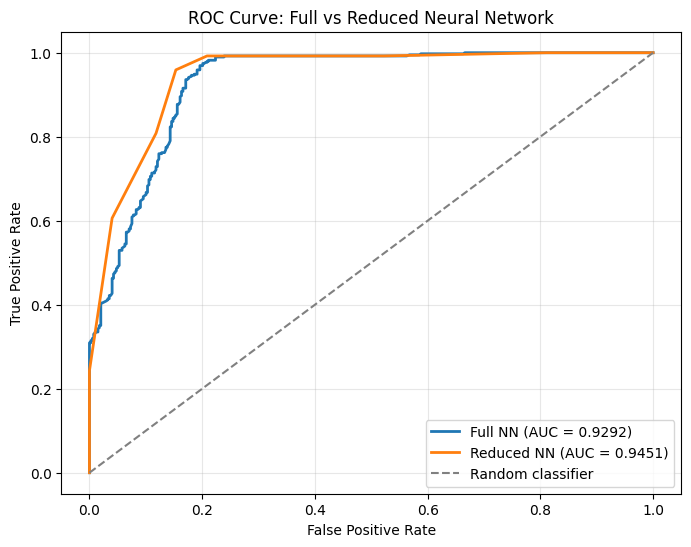

Full neural network AUC: 0.9292
Reduced neural network AUC: 0.9451


In [ ]:
y_prob_nn = best_nn.predict_proba(X_test_nn)[:, 1]
y_prob_nn_reduced = best_nn_reduced.predict_proba(X_test_reduced_nn)[:, 1]

fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)
fpr_nn_reduced, tpr_nn_reduced, _ = roc_curve(y_test, y_prob_nn_reduced)

auc_nn = auc(fpr_nn, tpr_nn)
auc_nn_reduced = auc(fpr_nn_reduced, tpr_nn_reduced)

plt.figure(figsize=(8, 6))
plt.plot(fpr_nn, tpr_nn, label=f'Full NN (AUC = {auc_nn:.4f})', linewidth=2)
plt.plot(fpr_nn_reduced, tpr_nn_reduced, label=f'Reduced NN (AUC = {auc_nn_reduced:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Full vs Reduced Neural Network')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f'Full neural network AUC: {auc_nn:.4f}')
print(f'Reduced neural network AUC: {auc_nn_reduced:.4f}')

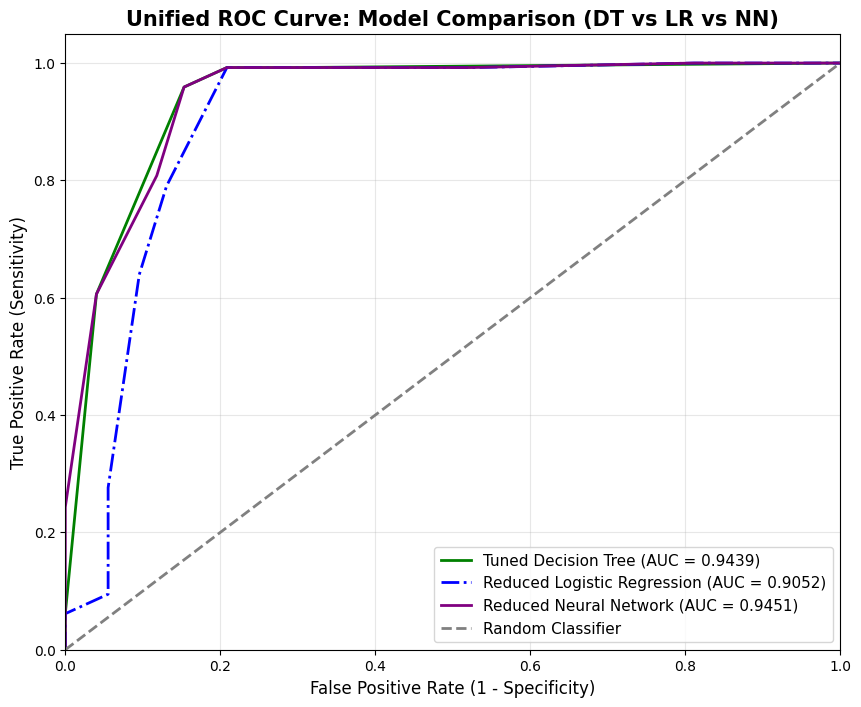

In [ ]:
y_prob_dt = best_dt.predict_proba(X_test)[:, 1]
y_prob_lr = best_lr_reduced.predict_proba(X_test_reduced)[:, 1]
y_prob_nn = best_nn_reduced.predict_proba(X_test_reduced_nn)[:, 1]

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = auc(fpr_dt, tpr_dt)

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)
auc_nn = auc(fpr_nn, tpr_nn)

plt.figure(figsize=(10, 8))
plt.plot(fpr_dt, tpr_dt, color='green', lw=2, 
         label=f'Tuned Decision Tree (AUC = {auc_dt:.4f})')
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, linestyle='-.', 
         label=f'Reduced Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot(fpr_nn, tpr_nn, color='purple', lw=2, linestyle='-', 
         label=f'Reduced Neural Network (AUC = {auc_nn:.4f})')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--', label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('Unified ROC Curve: Model Comparison (DT vs LR vs NN)', fontsize=15, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

plt.show()